# Chạy Thực Nghiệm Đồ Án (Continual Learning)
Notebook này được thiết kế ĐỘC QUYỀN để chạy toàn bộ file `run_experiments.sh` tự động trên Kaggle.

**HƯỚNG DẪN:**
1. Bật GPU (T4 x2 hoặc P100) trong Settings của Kaggle.
2. Chạy Ô Số 1 để cài đặt môi trường.
3. Bấm **Restart Session / Restart Kernel** khi Kaggle yêu cầu.
4. Chạy Ô Số 2 để bắt đầu quá trình huấn luyện toàn bộ các thực nghiệm (sẽ tốn khoảng 2-3 tiếng, cứ treo máy để đó).

In [1]:
# Ô SỐ 1: CÀI ĐẶT MÔI TRƯỜNG VÀ TẢI MÃ NGUỒN
!git clone https://github.com/quachthanhhmd/bilevel-coresets.git
%cd bilevel-coresets

Cloning into 'bilevel-coresets'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (333/333), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 333 (delta 165), reused 312 (delta 144), pack-reused 0 (from 0)
Receiving objects: 100% (333/333), 658.94 KiB | 15.32 MiB/s, done.
Resolving deltas: 100% (165/165), done.
/kaggle/working/bilevel-coresets


In [2]:
!git checkout bugfix/fixing-jax-error

Branch 'bugfix/fixing-jax-error' set up to track remote branch 'bugfix/fixing-jax-error' from 'origin'.
Switched to a new branch 'bugfix/fixing-jax-error'


⚠️ **CẢNH BÁO QUAN TRỌNG:** Dừng lại tại đây! Bạn phải bấm `Restart Session` (hoặc `Restart Kernel`) trước khi chạy ô tiếp theo.

In [3]:
# 1. Hạ cấp setuptools để vá lỗi môi trường build của Python 3.12
!pip install "setuptools<70.0.0"

# 2. Cài duy nhất thư viện mô phỏng mạng CNN còn thiếu
!pip install neural-tangents

!pip install --upgrade jax jaxlib==0.1.56+cuda101 -f https://storage.googleapis.com/jax-releases/jax_releases.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 kB 20.3 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.7/248.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 7.2 MB/s eta 0:00:00
Looking in links: https://storage.googleapis.com/jax-releases/jax_releases.html
ERROR: Ignored the following yanked versions: 0.4.32
ERROR: Could not find a version that satisfies the requirement jaxlib==0.1.56+cuda101 (from versions: 0.4.17, 0.4.18, 0.4.19, 0.4.20, 0.4.21, 0.4.22, 0.4.23, 0.4.24, 0.4.25, 0.4.26, 0.4.27, 0.4.28, 0.4.29, 0.4.30, 0.4.31, 0.4.32, 0.4.33, 0.4.34, 0.4.35, 0.4.36, 0.4.38, 0.5.0, 0.5.1, 0.5.3, 0.6.0, 0.6.1, 0.6.2, 0.7.0, 0.7.1, 0.7.2, 0.8.0, 0.8.1, 0.8.2, 0.8.3, 0.9.0, 0.9.0.1, 0.9.1, 0.9.2, 0.10.0, 0.10.1, 0.10.2, 0.11.0)
ERROR: No matching distribution fo

In [4]:
import jax
import jax.core
import jax._src.core
import jax.tree_util
import jax.util

# 1. Vá các class lõi bị giấu (Đã thêm Primitive)
missing_classes = [
    'Jaxpr', 'JaxprEqn', 'Literal', 'Var', 'DropVar', 
    'ClosedJaxpr', 'ShapedArray', 'Value', 'MainTrace', 'Trace',
    'Primitive'  # <--- CHÍNH LÀ THỦ PHẠM MỚI NHẤT
]
for cls_name in missing_classes:
    if hasattr(jax._src.core, cls_name):
        setattr(jax.core, cls_name, getattr(jax._src.core, cls_name))

# 2. Vá hàm tree_multimap
if not hasattr(jax.tree_util, 'tree_multimap'):
    jax.tree_util.tree_multimap = jax.tree_util.tree_map

# 3. Vá hàm safe_map và safe_zip cho jax.util
def custom_safe_map(f, *args):
    return list(map(f, *args))

def custom_safe_zip(*args):
    return list(zip(*args))

jax.util.safe_map = custom_safe_map
jax.util.safe_zip = custom_safe_zip

print("Đã vá nóng JAX V4: Bổ sung Primitive! Sẵn sàng nạp Neural Tangents.")

Đã vá nóng JAX V4: Bổ sung Primitive! Sẵn sàng nạp Neural Tangents.


In [5]:
# # Ô SỐ 2: HUẤN LUYỆN (nặng, cần GPU) — chỉ ghi ra cl_results/*.txt, KHÔNG vẽ biểu đồ
# # Lưu ý: Lệnh %cd giúp đảm bảo thư mục làm việc luôn nằm trong repo sau khi restart kernel.
# %cd /kaggle/working/bilevel-coresets

# # Chấp quyền thực thi cho file bash
# !chmod +x run_experiments.sh

# # Khởi chạy thực nghiệm trên tập FashionMNIST, so sánh Uniform, KMeans, Sensitivity Coreset, GLISTER và Coreset (Bilevel)
# !./run_experiments.sh --dataset splitfashionmnist --methods uniform,kmeans_features,sensitivity,glister,coreset --stage train

🎉 **LẤY KẾT QUẢ:** Sau khi ô số 2 chạy xong (khoảng vài tiếng), kết quả tổng hợp sẽ in ra ngay trên màn hình. Các file kết quả chi tiết `.txt` (chứa dữ liệu dạng JSON) sẽ nằm trong thư mục `cl_streaming/cl_results/`. Bạn có thể tải thư mục này về máy tính.

In [6]:
# %cd /kaggle/working/bilevel-coresets
# !./run_experiments.sh --dataset splitfashionmnist --methods uniform,kmeans_features,sensitivity,glister,coreset --stage report

In [7]:
# from IPython.display import Image, display

# for img_name in [
#     'average_forgetting.png',
#     'tradeoff_time_accuracy.png',
#     'baseline_accuracy_comparison.png',
#     'baseline_forgetting_comparison.png',
#     'baseline_tradeoff_comparison.png',
# ]:
#     img_path = f'experiments/{img_name}'
#     print(f'--- {img_name} ---')
#     display(Image(filename=img_path))

## Các demo

In [8]:
import subprocess

# 1. Đường tham chiếu "Full Dataset"
subprocess.run(['python', 'experiments/run_algorithm1_variants_fashion.py',
                '--method', 'full', '--seed', '0'], check=True)

sizes = [50, 100, 200, 400, 800]

# 2. 5 phương pháp còn lại (không cần tham số riêng)
for method in ['uniform', 'bico_fwd', 'bico_fwd_b', 'bico_elim', 'bico_exch']:
    for size in sizes:
        subprocess.run(['python', 'experiments/run_algorithm1_variants_fashion.py',
                        '--method', method, '--size', str(size), '--seed', '0'], check=True)

# 3. bico_reg -- dùng tham số đã tăng để đường tím ổn định hơn
for size in sizes:
    subprocess.run(['python', 'experiments/run_algorithm1_variants_fashion.py',
                    '--method', 'bico_reg', '--size', str(size), '--seed', '0',
                    '--reg-outer-it', '150', '--reg-warm-inner-it', '30'], check=True)

device: cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.4MB/s]


training set: 60000 images, test set: 10000 images
full dataset (n=60000): 91.55%  [train 353.3s]
device: cuda
training set: 60000 images, test set: 10000 images
uniform (m=50, seed=0): 58.79%  [build 0.0s, train 12.7s]
device: cuda
training set: 60000 images, test set: 10000 images
uniform (m=100, seed=0): 67.76%  [build 0.0s, train 20.9s]
device: cuda
training set: 60000 images, test set: 10000 images
uniform (m=200, seed=0): 73.06%  [build 0.0s, train 40.8s]
device: cuda
training set: 60000 images, test set: 10000 images
uniform (m=400, seed=0): 77.66%  [build 0.0s, train 81.2s]
device: cuda
training set: 60000 images, test set: 10000 images
uniform (m=800, seed=0): 82.38%  [build 0.0s, train 165.9s]
device: cuda
training set: 60000 images, test set: 10000 images
bico_fwd (m=50, seed=0): 68.23%  [build 50.2s, train 11.7s]
device: cuda
training set: 60000 images, test set: 10000 images
bico_fwd (m=100, seed=0): 75.64%  [build 113.0s, train 20.5s]
device: cuda
training set: 60000 imag

In [9]:
subprocess.run(['python', 'experiments/algorithm1_variants_fashion_plot.py',
                '--sizes', '50,100,200,400,800', '--seeds', '0'], check=True)

Saved plot to /kaggle/working/bilevel-coresets/experiments/algorithm1_variants_fashion_accuracy.png


CompletedProcess(args=['python', 'experiments/algorithm1_variants_fashion_plot.py', '--sizes', '50,100,200,400,800', '--seeds', '0'], returncode=0)

In [10]:
!python demos/demo_logistic_regression.py --dataset fashion


== fashion Pullover-vs-Shirt (784d, 4000pts) == (full-data test accuracy = 0.7767) ==
size=  5  BiCo w/ Weights=0.5625  BiCo=0.6244  k-means++=0.5561  Sensitivity Coreset=0.5697
size= 15  BiCo w/ Weights=0.6314  BiCo=0.6278  k-means++=0.5711  Sensitivity Coreset=0.6347
size= 30  BiCo w/ Weights=0.6836  BiCo=0.6778  k-means++=0.6669  Sensitivity Coreset=0.7261
size= 50  BiCo w/ Weights=0.7203  BiCo=0.6744  k-means++=0.7086  Sensitivity Coreset=0.6317
avg construction time: BiCo w/ Weights=4.56s, BiCo=1.15s (weighted is 4.0x slower)

Saved plot to /kaggle/working/bilevel-coresets/demos/logistic_regression_coreset_accuracy.png


## Continual Learning đầy đủ — Table 3 (Sec 5.3)

Paper dùng 13 phương pháp cho Table 3, bạn mới chạy 5 (`uniform`, `kmeans_features`, `sensitivity`, `glister`, `coreset`). Ô dưới chạy nốt các phương pháp còn thiếu, cùng `buffer_size=100, beta=1.0` để so sánh được trên cùng biểu đồ. `forgetting` (Toneva et al., 2019) là baseline mới vừa được thêm vào code.

**Lưu ý:** cần `git pull` (hoặc clone lại) bản mới nhất của nhánh `bugfix/fixing-jax-error` trước khi chạy — các phương pháp/hàm dưới đây chỉ có nếu code đã được cập nhật.

In [11]:
import subprocess, os

remaining_table3_methods = [
    'kcenter_features', 'kmeans_grads', 'kmeans_embedding',
    'kcenter_embedding', 'kcenter_grads', 'grad_matching',
    'entropy', 'hardest', 'frcl', 'icarl', 'forgetting',
]

# cl.py chỉ import đúng (loss_utils, models, bilevel_coreset ở repo root; cl_streaming
# như một package) khi được chạy với cwd=cl_streaming/ VÀ repo root nằm trong PYTHONPATH
# -- đúng như run_experiments.sh làm (cd cl_streaming && export PYTHONPATH=..:$PYTHONPATH).
# Gọi thẳng 'python cl_streaming/cl.py' từ repo root sẽ lỗi ModuleNotFoundError: loss_utils.
repo_root = os.getcwd()
cl_dir = os.path.join(repo_root, 'cl_streaming')
env = os.environ.copy()
env['PYTHONPATH'] = repo_root + os.pathsep + env.get('PYTHONPATH', '')

for method in remaining_table3_methods:
    subprocess.run(['python', 'cl.py',
                    '--dataset', 'splitfashionmnist', '--method', method,
                    '--seed', '0', '--buffer_size', '100', '--beta', '1.0'],
                   cwd=cl_dir, env=env, check=True)


Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitfashionmnist', method='kcenter_features', device='cuda', samples_per_task=1000, buffer_size=100, batch_size=256, num_workers=0)


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.4MB/s]


Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitfashionmnist', method='kmeans_grads', device='cuda', samples_per_task=1000, buffer_size=100, batch_size=256, num_workers=0)
Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitfashionmnist', method='kmeans_embedding', device='cuda', samples_per_task=1000, buffer_size=100, batch_size=256, num_workers=0)
Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitfashionmnist', method='kcenter_embedding', device='cuda', samples_per_task=1000, buffer_size=100, batch_size=256, num_workers=0)
Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitfashionmnist', method='kcenter_grads', device='cuda', samples_per_task=1000, buffer_size=100, batch_size=256, num_workers=0)
Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitfashionmnist', method='grad_matching', device='cuda', samples_per_task=1000, buffer_size=100, batch_size=256, num_workers=0)
Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitfashionmnist', method='entr

## Vẽ lại biểu đồ với đầy đủ các phương pháp

`baseline_comparison_plot.py` giờ đã biết đủ 15 phương pháp (Table 3 gốc paper + 2 baseline bạn tự thêm). Phương pháp nào chưa có file kết quả sẽ tự bị bỏ qua (in cảnh báo), không bịa số.

Đã lưu biểu đồ So sánh Độ chính xác tại: /kaggle/working/bilevel-coresets/experiments/baseline_accuracy_comparison.png
Đã lưu biểu đồ So sánh Forgetting tại: /kaggle/working/bilevel-coresets/experiments/baseline_forgetting_comparison.png
Đã lưu biểu đồ Trade-off tại: /kaggle/working/bilevel-coresets/experiments/baseline_tradeoff_comparison.png
Đã lưu biểu đồ Ablation tại: /kaggle/working/bilevel-coresets/experiments/coreset_ablation.png
--- baseline_accuracy_comparison.png ---


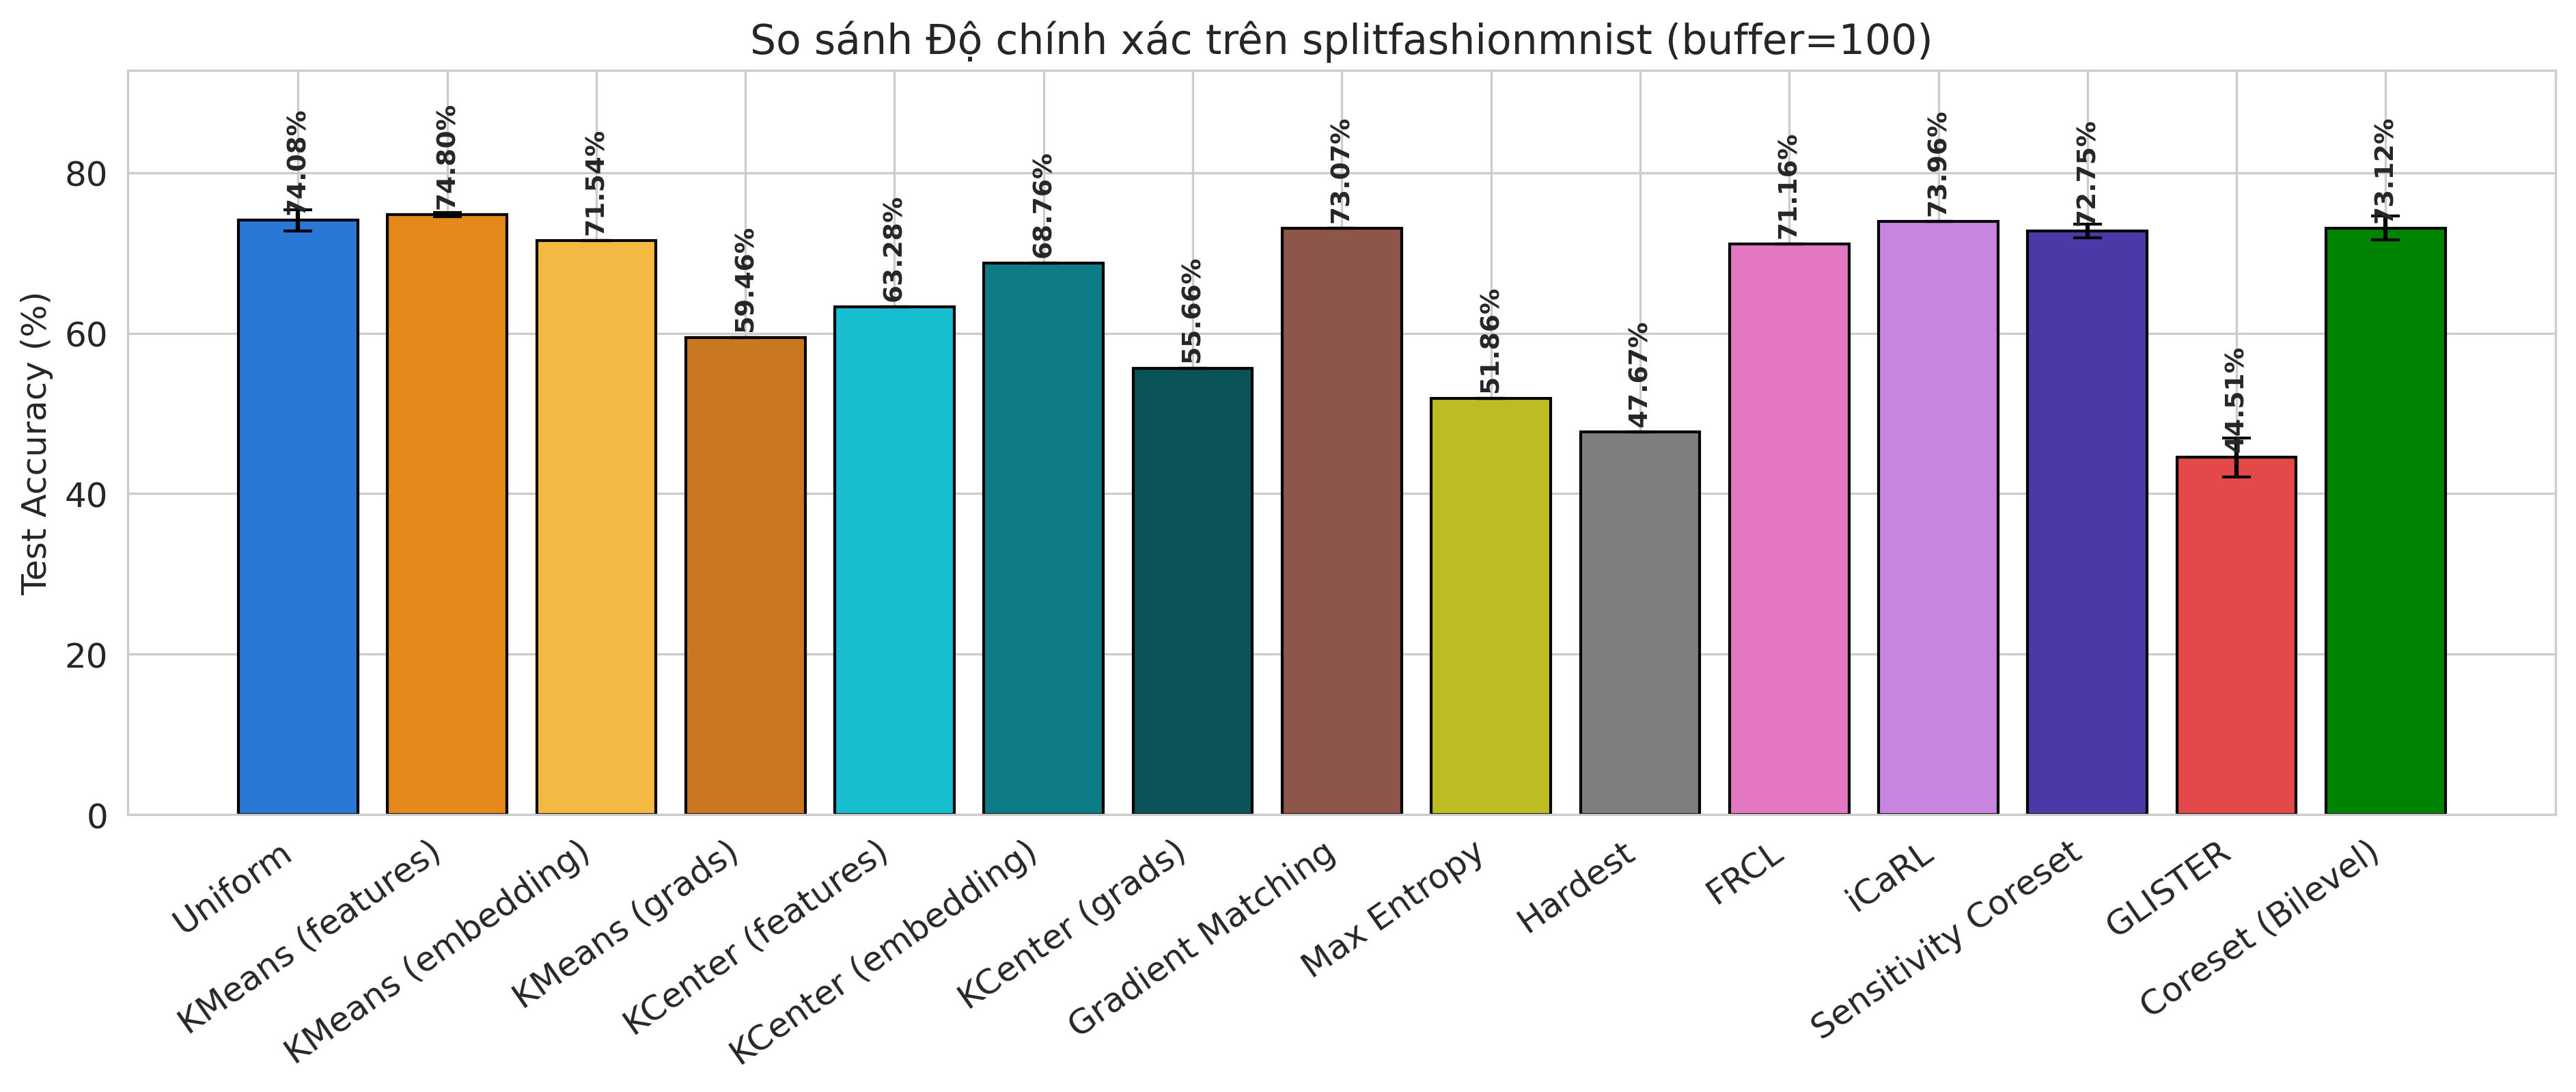

--- baseline_forgetting_comparison.png ---


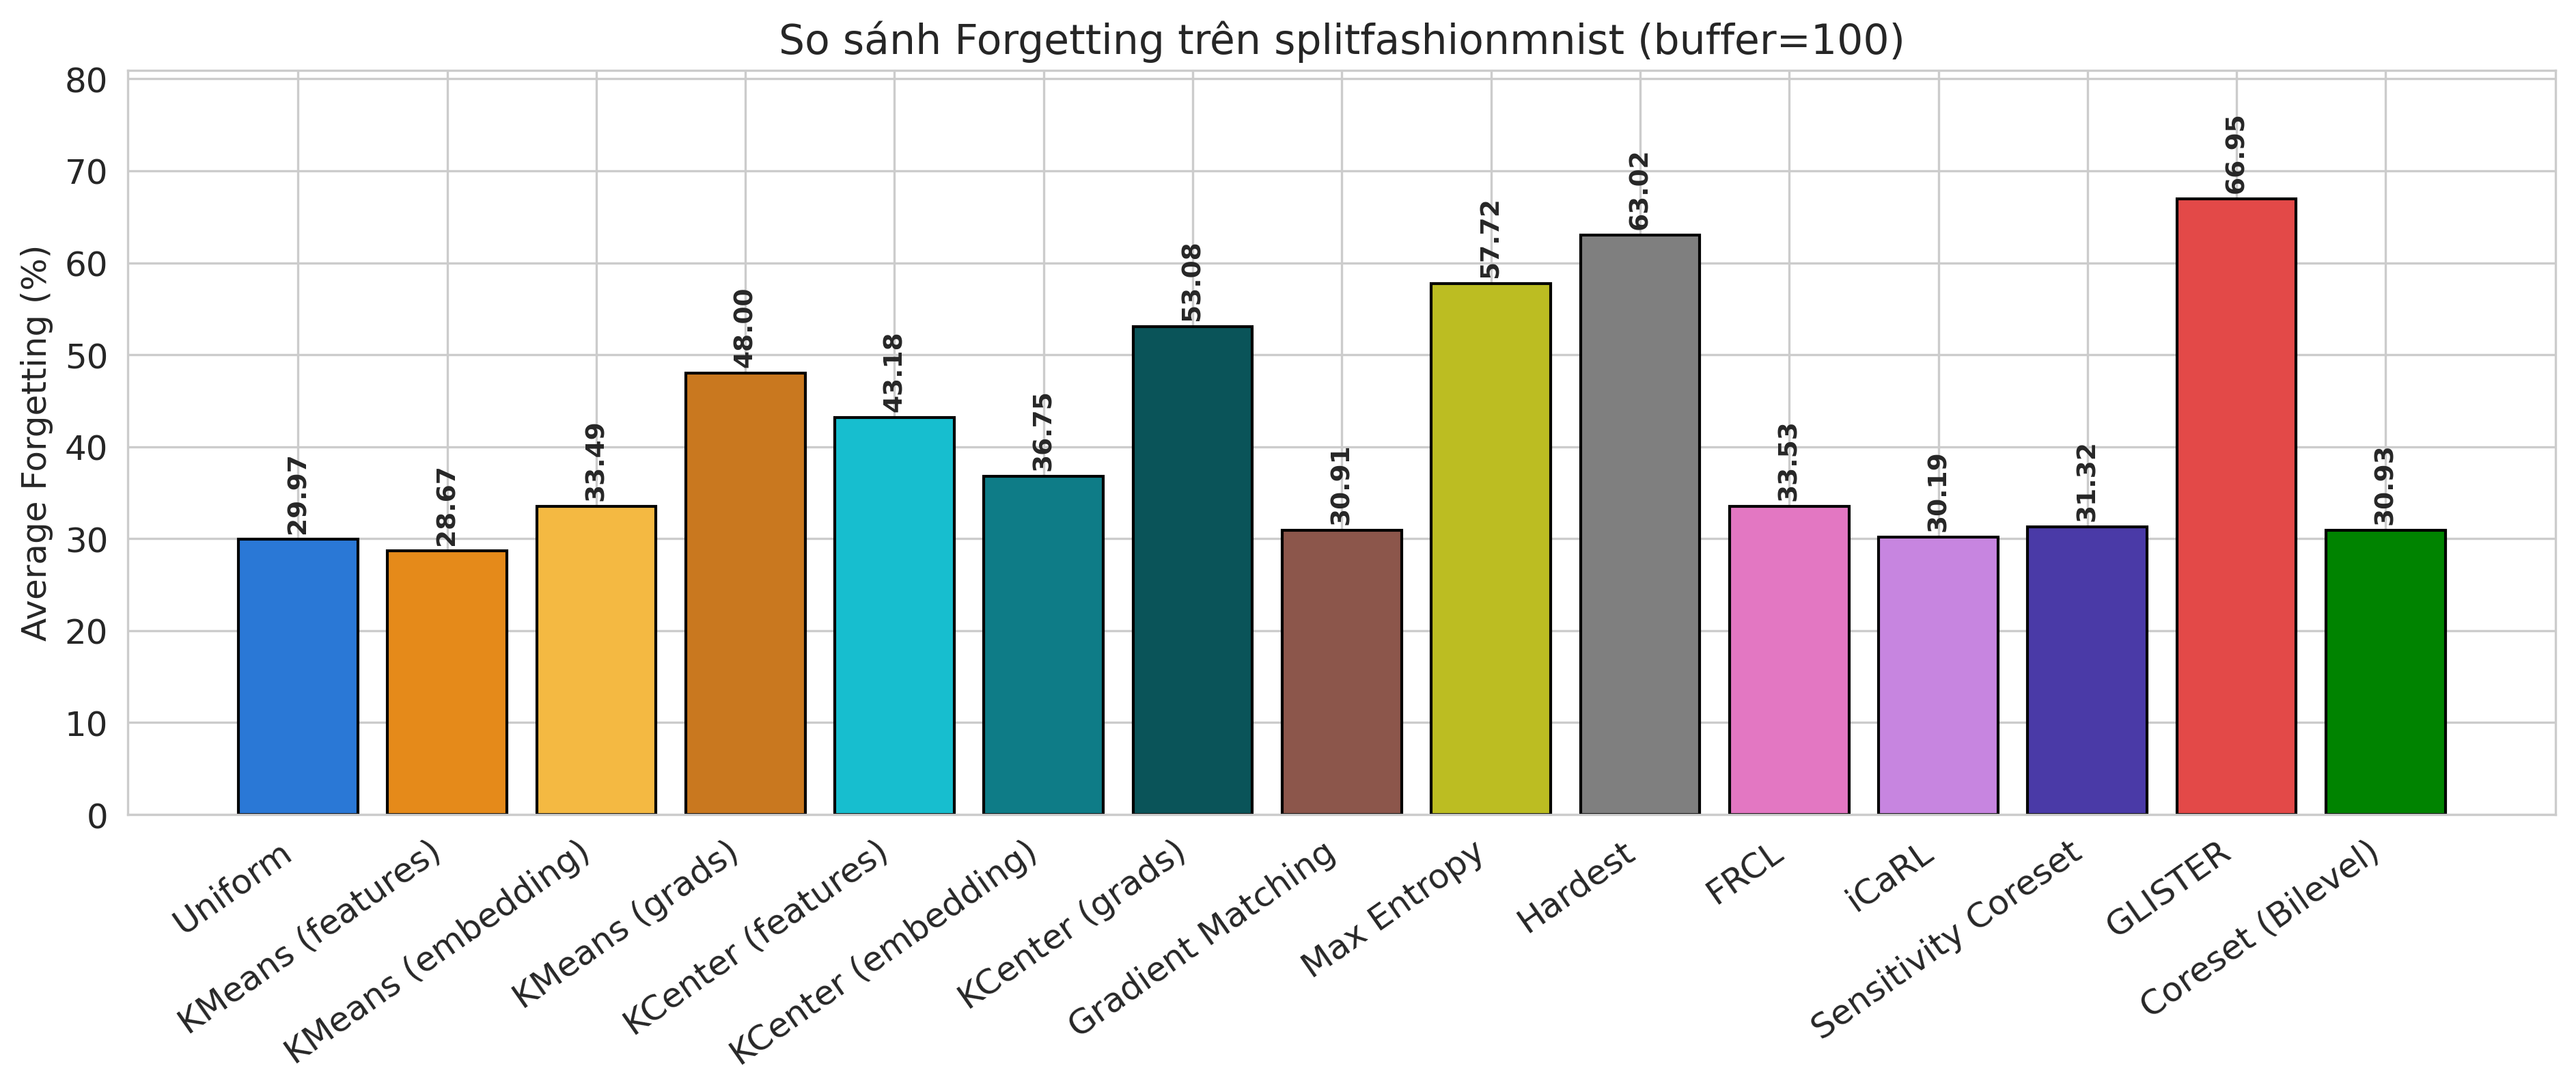

--- baseline_tradeoff_comparison.png ---


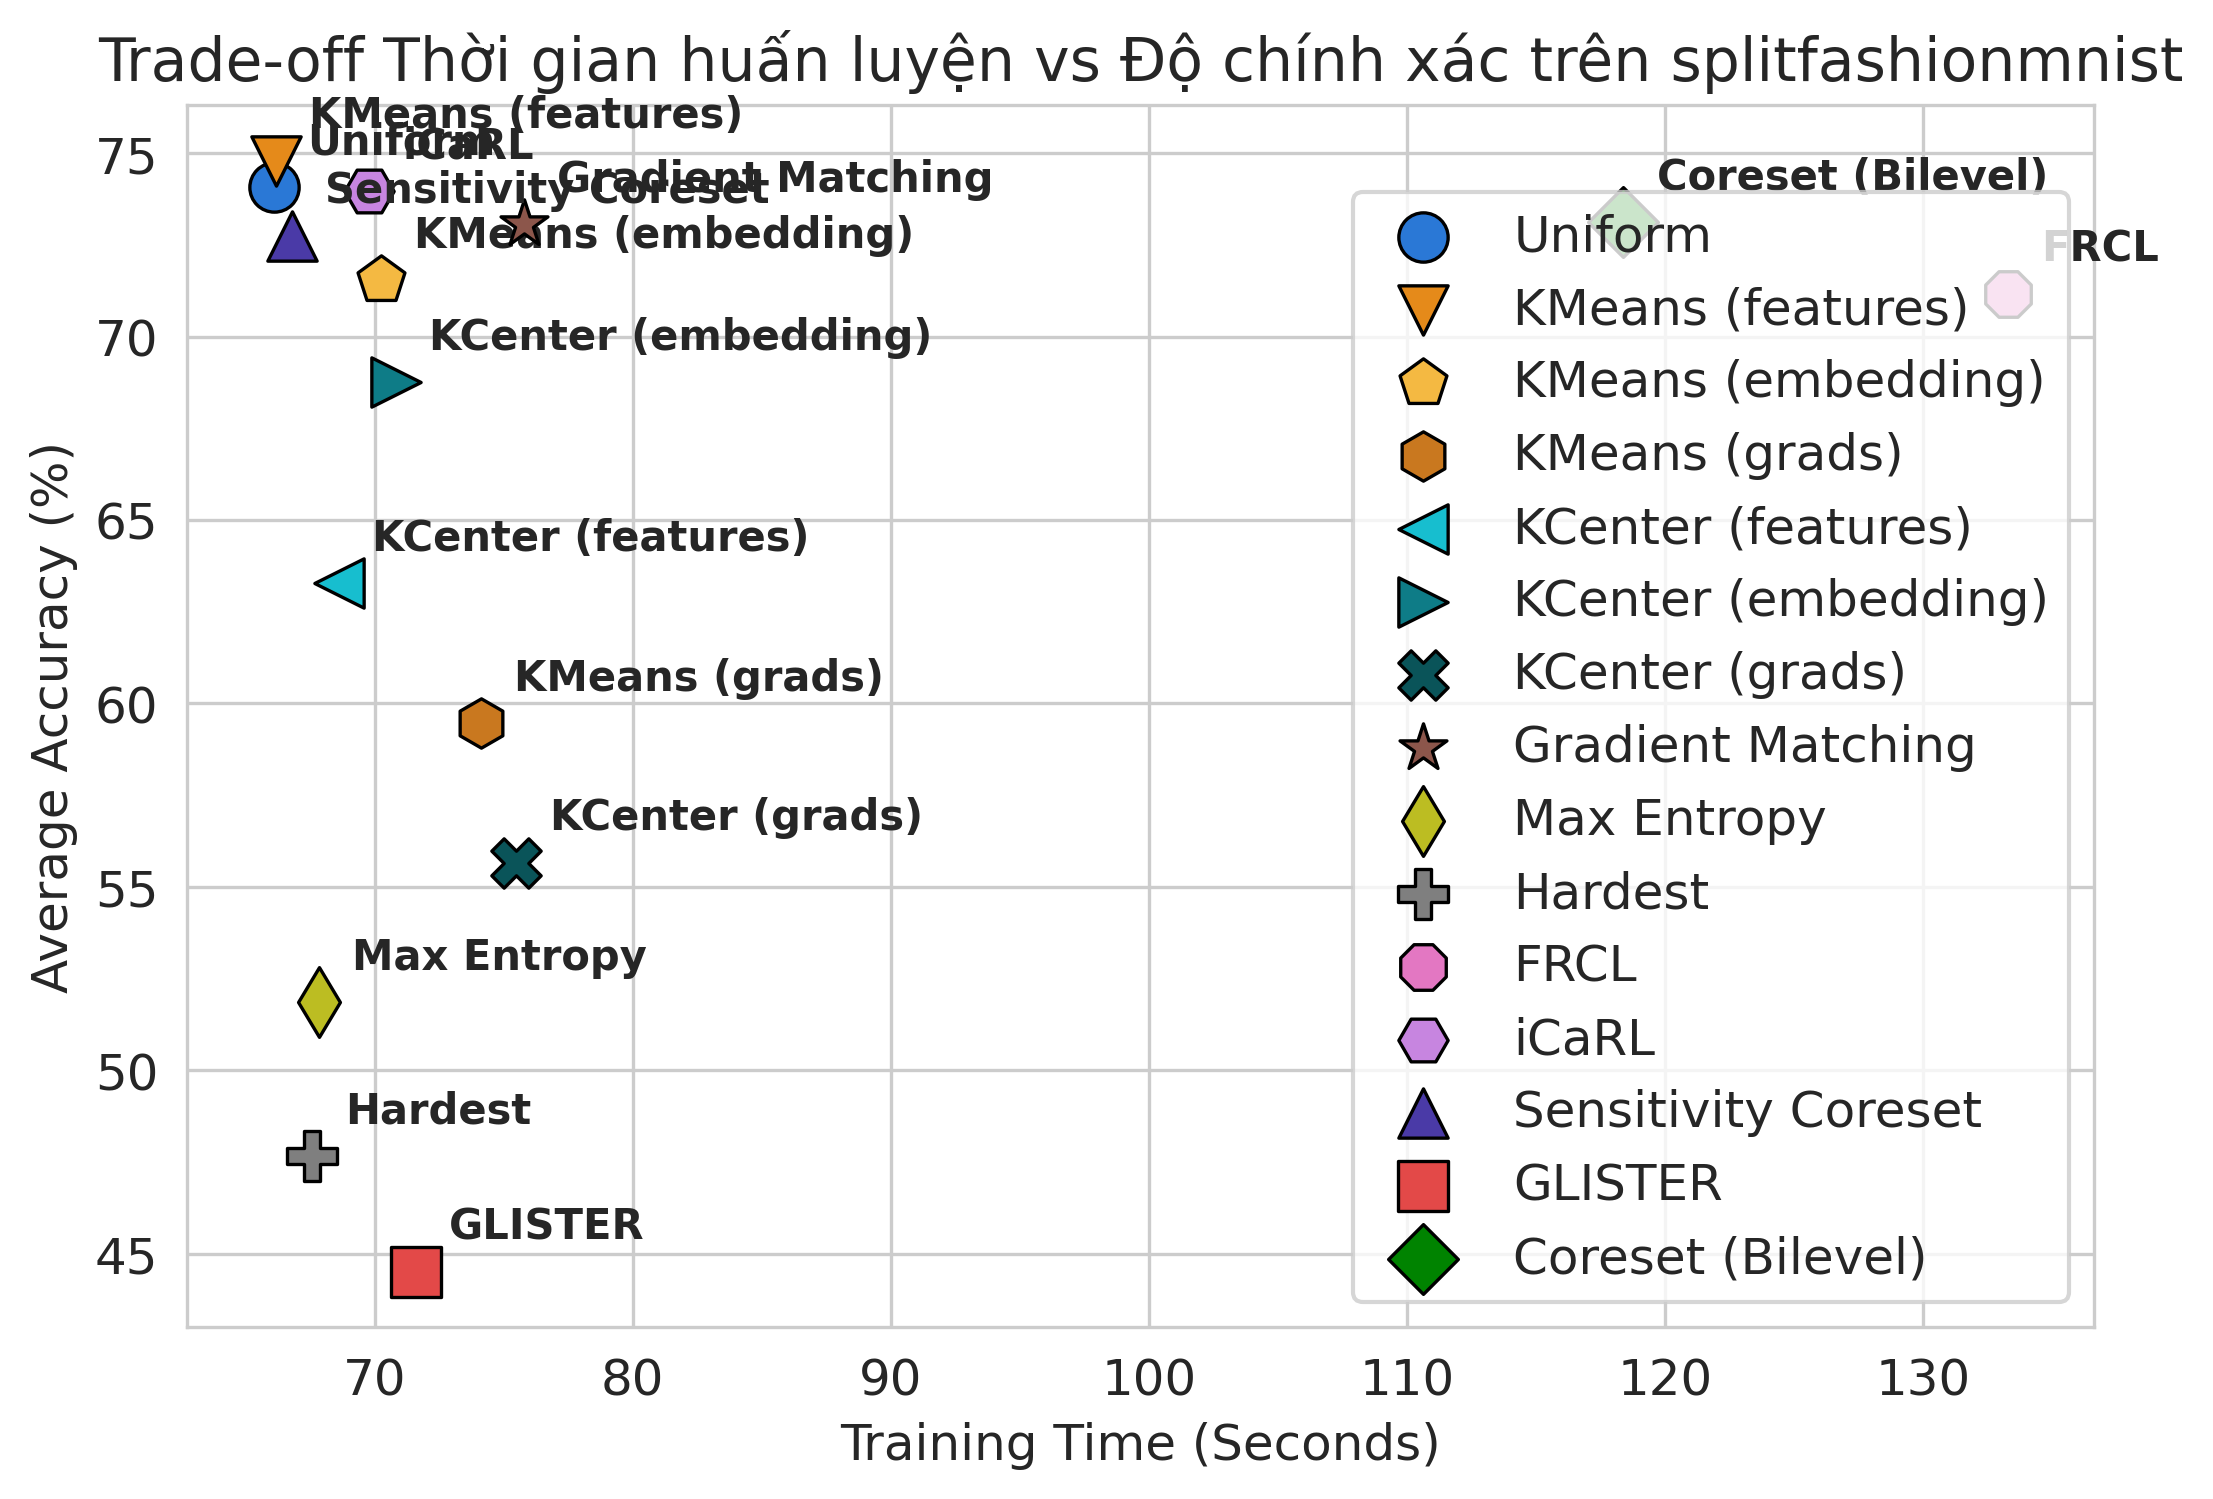

In [12]:
subprocess.run(['python', 'experiments/baseline_comparison_plot.py',
                '--plot', 'all', '--dataset', 'splitfashionmnist', '--seeds', '0,1,2'], check=True)

from IPython.display import Image, display
for img_name in [
    'baseline_accuracy_comparison.png',
    'baseline_forgetting_comparison.png',
    'baseline_tradeoff_comparison.png',
]:
    print(f'--- {img_name} ---')
    display(Image(filename=f'experiments/{img_name}'))


## Streaming — Sec 5.4 (Table 5)

So sánh coreset (qua NTK proxy) với reservoir sampling và CBRS trong bối cảnh streaming (không phải continual learning theo task). `streaming.py` giờ đã hỗ trợ `splitfashionmnist`. `reservoir`/`cbrs` không cần jax; `coreset` cần NTK proxy (đã cài ở Ô số 1).

In [13]:
import subprocess, os

repo_root = os.getcwd()
cl_dir = os.path.join(repo_root, 'cl_streaming')
env = os.environ.copy()
env['PYTHONPATH'] = repo_root + os.pathsep + env.get('PYTHONPATH', '')

for method in ['reservoir', 'cbrs', 'coreset']:
    subprocess.run(['python', 'streaming.py',
                    '--dataset', 'splitfashionmnist', '--method', method,
                    '--seed', '0', '--buffer_size', '100', '--beta', '1.0'],
                   cwd=cl_dir, env=env, check=True)


Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitfashionmnist', method='reservoir', device='cuda', samples_per_task=1000, buffer_size=100, stream_batch_size=125, nr_slots=10, num_workers=0, batch_size=256)
Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitfashionmnist', method='cbrs', device='cuda', samples_per_task=1000, buffer_size=100, stream_batch_size=125, nr_slots=10, num_workers=0, batch_size=256)
Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitfashionmnist', method='coreset', device='cuda', samples_per_task=1000, buffer_size=100, stream_batch_size=125, nr_slots=10, num_workers=0, batch_size=256)


## Streaming mất cân bằng — Table 6

4 task đầu chỉ giữ 200 điểm, task cuối giữ 2000 điểm (giả lập luồng dữ liệu mất cân bằng). Paper dùng `nr_slots=1` cho thí nghiệm này. `coreset` không được so sánh ở đây (paper chỉ so `reservoir` với `cbrs` cho Table 6).

In [14]:
import subprocess, os

repo_root = os.getcwd()
cl_dir = os.path.join(repo_root, 'cl_streaming')
env = os.environ.copy()
env['PYTHONPATH'] = repo_root + os.pathsep + env.get('PYTHONPATH', '')

for method in ['reservoir', 'cbrs']:
    subprocess.run(['python', 'streaming.py',
                    '--dataset', 'splitfashionmnistimbalanced', '--method', method,
                    '--seed', '0', '--buffer_size', '100', '--beta', '1.0',
                    '--nr_slots', '1'],
                   cwd=cl_dir, env=env, check=True)


Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitfashionmnistimbalanced', method='reservoir', device='cuda', samples_per_task=1000, buffer_size=100, stream_batch_size=125, nr_slots=1, num_workers=0, batch_size=256)
Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitfashionmnistimbalanced', method='cbrs', device='cuda', samples_per_task=1000, buffer_size=100, stream_batch_size=125, nr_slots=1, num_workers=0, batch_size=256)


## Xem kết quả Streaming (Table 5 + Table 6)

Chưa có script vẽ biểu đồ riêng cho streaming (paper trình bày dạng bảng số, không phải hình) — ô dưới in trực tiếp từ file JSON.

In [15]:
import json, os

def load_streaming(dataset, methods, buffer_size=100, beta=1.0, seed=0):
    rows = []
    for method in methods:
        path = f'cl_streaming/streaming_results/{dataset}_{method}_{buffer_size}_{beta}_{seed}.txt'
        if os.path.exists(path):
            with open(path) as f:
                d = json.load(f)
            rows.append((method, d['test_acc'], d['acc_per_task']))
        else:
            rows.append((method, None, None))
    return rows

print('=== Table 5: Streaming (balanced) ===')
for method, acc, per_task in load_streaming('splitfashionmnist', ['reservoir', 'cbrs', 'coreset']):
    print(f'{method:12s} {("%.2f" % acc) if acc is not None else "chưa chạy"}')

print()
print('=== Table 6: Streaming (imbalanced) ===')
for method, acc, per_task in load_streaming('splitfashionmnistimbalanced', ['reservoir', 'cbrs']):
    print(f'{method:12s} {("%.2f" % acc) if acc is not None else "chưa chạy"}')


=== Table 5: Streaming (balanced) ===
reservoir    73.37
cbrs         72.88
coreset      69.28

=== Table 6: Streaming (imbalanced) ===
reservoir    63.30
cbrs         72.26


## Kiểm chứng hằng số chuẩn hóa FashionMNIST (0.2860, 0.3530)

`cl_streaming/datagen.py` dùng `transforms.Normalize((0.2860,), (0.3530,))` cho FashionMNIST. Ô dưới tính lại mean/std thật từ toàn bộ 60000 ảnh train (không phải ước lượng trên mẫu con) và vẽ biểu đồ so sánh — dùng làm bằng chứng trong báo cáo.

Tính từ toàn bộ 60000 ảnh train FashionMNIST (47040000 pixel, thang [0, 1]):
  mean = 0.286041   (code dùng 0.286, lệch 0.000041 = 0.014%)
  std  = 0.353024   (code dùng 0.353, lệch 0.000024 = 0.007%)
Saved plot to /kaggle/working/bilevel-coresets/experiments/fashion_normalization_verification.png


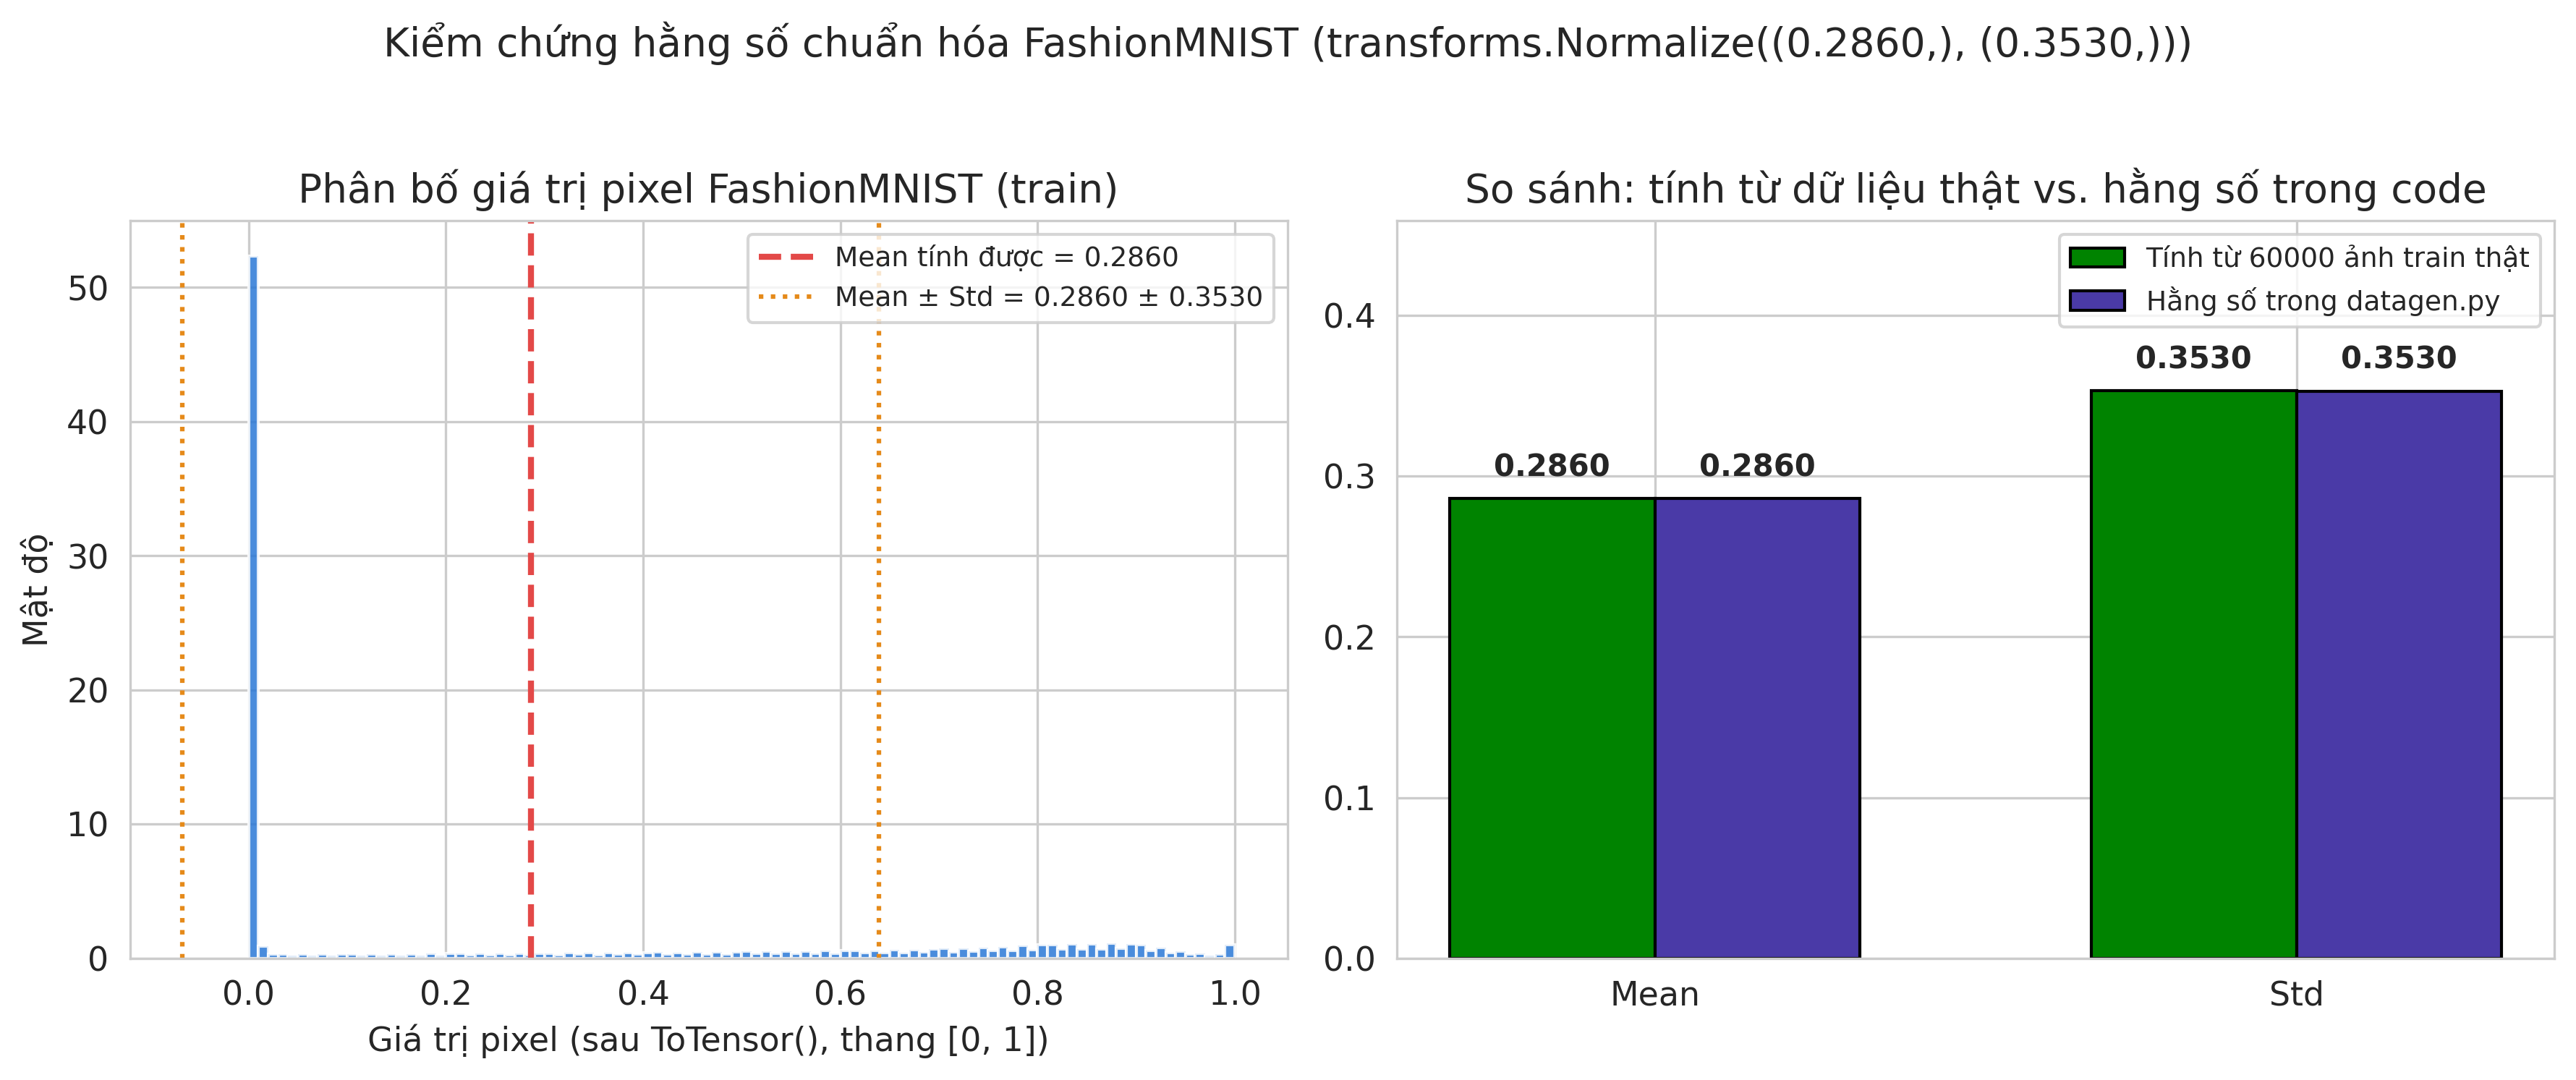

In [16]:
subprocess.run(['python', 'experiments/verify_fashion_normalization.py'], check=True)

from IPython.display import Image, display
display(Image(filename='experiments/fashion_normalization_verification.png'))
